In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import airy

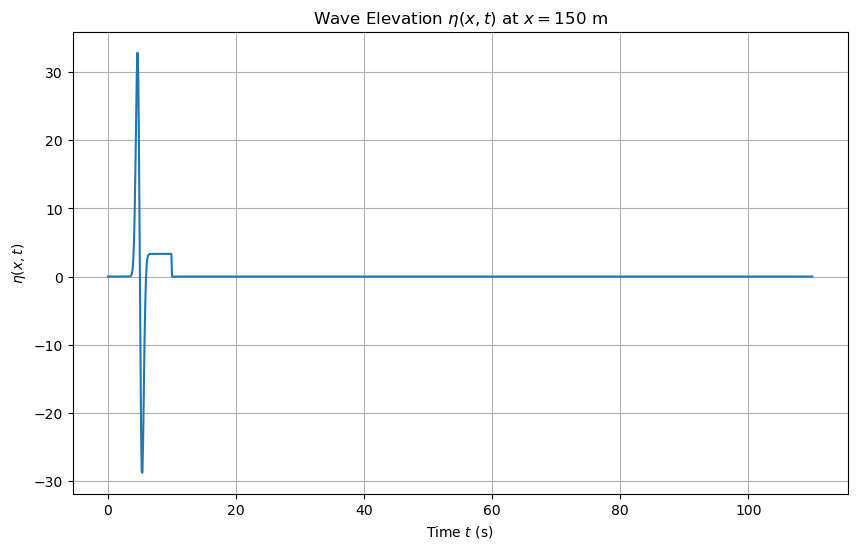

In [3]:
def plot_eta(x_target):

    h0 = 100
    alpha = 0.1
    g = 9.8
    LV = 100 # Box length = 50m; Velocity = 2m/s
    t_immersed = 5 # Box thickness = 20m ; time = 20/2 = 10
    rho = 1000
    PL = 5e6 # Pressure is 1e5 Pa
    epsilon = 0.5 # Width of pulse

    h_x = h0 - alpha * x_target

    tau_x = (2 / (alpha * np.sqrt(g))) * (np.sqrt(h0) - np.sqrt(h_x))

    t_end = tau_x + t_immersed + 100 # So as not to trim the graph
    t = np.linspace(0, t_end, 1000)

    t_prime = t - tau_x # Time lag to give to piecewise function

    # Piecewise u function
    u = np.where((t_prime >= 0) & (t_prime <= t_immersed), LV / h0, 0.0)

    amp1 = (h0 / h_x)**0.25 * (h0 / g)**0.5
    eta_1 = amp1 * u

    amp2 = (h0 / h_x)**0.25 * (PL) / (rho * g * np.sqrt(g * h0))
    d_delta = (-2 * t_prime / (epsilon**3 * np.sqrt(np.pi))) * np.exp(-(t_prime / epsilon)**2)

    eta_2 = amp2 * d_delta

    eta_total = eta_1 + eta_2

    plt.figure(figsize=(10, 6))
    # plt.plot(t, eta_1, label=f'x_target = {x_target} m')
    # plt.plot(t, eta_2, label=f'x_target = {x_target} m')
    plt.plot(t, eta_total, label=f'x_target = {x_target} m')
    plt.title(f'Wave Elevation $\\eta(x,t)$ at $x = {x_target}$ m')
    plt.xlabel('Time $t$ (s)')
    plt.ylabel('$\\eta(x,t)$')
    plt.grid(True)
    plt.show()

plot_eta(150)

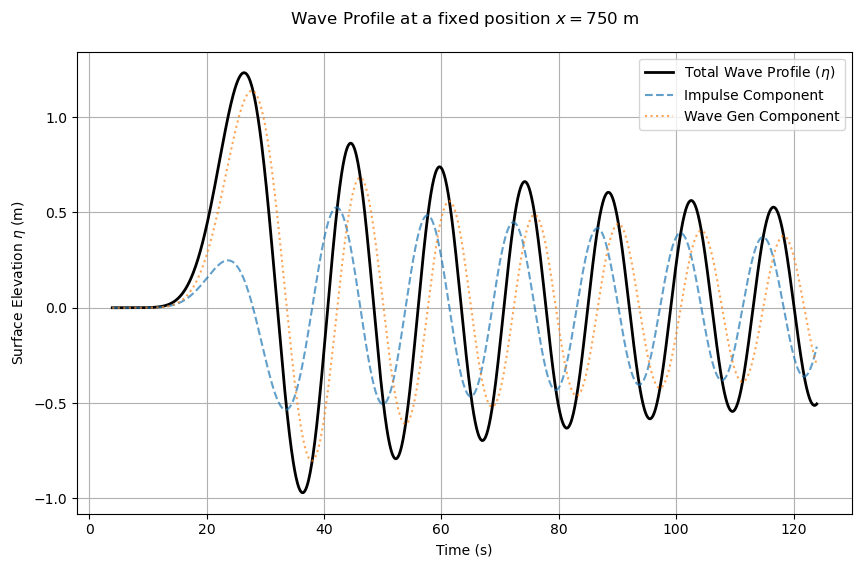

In [14]:
# Parameters and constants
g = 9.81 # Gravitational acceleration (m/s^2)
rho = 1000 # Density of water (kg/m^3)

# Lake configuration parameters
h0 = 100 # Initial water depth (m)
x_s = 500 # Coordinate where the flat bed ends (m)
theta = 10 # Slope angle in degrees
alpha = np.tan(np.radians(theta)) # Slope of the bed

# Landslide block parameters
L = 25.0 # Length of block
d = 12.0 # Depth of block
P = 5e5 # Initial impact pressure in pascals

# OBSERVATION POINT
x_obs = 750

# Local depth h(x) at observation point
if x_obs <= x_s:
    h_x = h0
else:
    h_x = max(1e-3, h0 - alpha * (x_obs - x_s))

shoaling_amp_vertical = (h0 / h_x) ** 0.25
shoaling_comp_horizontal = (h0 / h_x) ** 0.5

c0 = np.sqrt(g * h0)

t_arrival = x_obs / c0
t_start = max(0.1, t_arrival - 20.0) # Just to avoid division by zero
t_end = t_arrival + 100.0
t = np.linspace(t_start, t_end, 1500)

chi = (0.5 * c0 * (h0**2) * t) ** (1/3)

z_shoal = shoaling_comp_horizontal * ((x_obs - c0 * t) / chi)

# Components of Airy function
ai, aip, _, _ = airy(z_shoal)

# Impulse phase component
eta_I = - (P * L / (2 * rho)) * np.sqrt(h0/g) * (1 / (chi**2)) * aip

# Wave generator phase component
eta_V = (L * d / chi) * ai

eta_total = shoaling_amp_vertical * (eta_I + eta_V)

plt.figure(figsize=(10,6))

plt.plot(t, eta_total, label=r'Total Wave Profile ($\eta$)', linewidth = 2, color="black")
plt.plot(t, shoaling_amp_vertical * eta_I, label='Impulse Component', linestyle='--', alpha=0.7)
plt.plot(t, shoaling_amp_vertical * eta_V, label='Wave Gen Component', linestyle=':', alpha=0.7)

plt.title(f'Wave Profile at a fixed position $x = {x_obs}$ m\n')
plt.xlabel('Time (s)')
plt.ylabel(r'Surface Elevation $\eta$ (m)')

plt.grid(True)
plt.legend()
plt.show()